# Cluster maps

In [1]:
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
%matplotlib inline
import astropy.units as u
from astropy.coordinates import SkyCoord
import pyccl as ccl

from iminuit import Minuit
from iminuit.cost import LeastSquares

from simulMap import *

In [2]:
#resolution:
nside = 64
npix = hp.nside2npix(nside)
print("Number of pixels = {}".format(npix))

#sources:
NSource_px_th = int(1e6)
print("Total number of sources in the entire sky : {}".format(NSource_px_th*npix))
print("Theorical number of sources in one pixel : {}".format(NSource_px_th))

Number of pixels = 49152
Total number of sources in the entire sky : 49152000000
Theorical number of sources in one pixel : 1000000


## Power spectrum

/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: Nchi must be a positive integer. Setting to match tracer with fewest chi samples.
  warnings_builtin.warn(*args, **kwargs)
/home/victoria/miniconda3/envs/M2Stage/lib/python3.10/site-packages/pyccl/errors.py:22: CCLWarning: chi_min must be greater than zero.Setting to default 1e-6 Mpc.
  warnings_builtin.warn(*args, **kwargs)


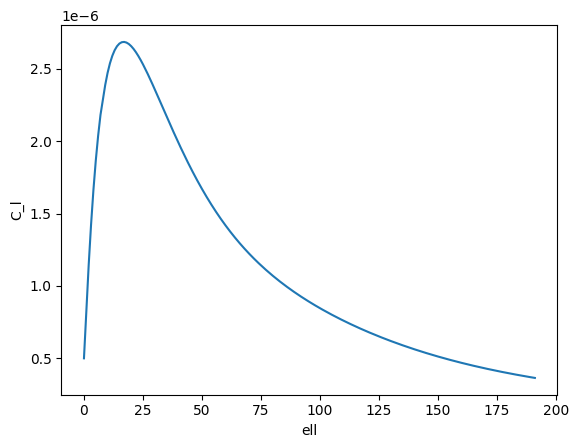

In [3]:
def nz_model(z):
    """Compute the normalized distribution in redshift dependong on the redshift z."""
    return z**2 * np.exp(-(z/0.5)**1.5)


def build_nz(zmin):
    z = np.linspace(0.01, 3.0, 400)
    nz = nz_model(z)
    nz[z < zmin] = 0
    nz /= np.trapz(nz, z)
    return z, nz


def get_Cl_ccl(nside, zmin, Omega_c=0.25, Omega_b=0.05, h=0.67, sigma8=0.8, n_s=0.96, get_ell=False, cosmo=None):
    lmax = 3*nside - 1
    if cosmo is None: cosmo = ccl.Cosmology(
        Omega_c=Omega_c,
        Omega_b=Omega_b,
        h=h,
        sigma8=sigma8,
        n_s=n_s
    )

    ell = np.arange(0, lmax+1)
    z, nz = build_nz(zmin)
    bias = np.ones_like(z)  # b=1
    tracer = ccl.NumberCountsTracer(
        cosmo,
        has_rsd=False,
        dndz=(z, nz),
        bias=(z, bias)
    )

    cl = ccl.angular_cl(cosmo, tracer, tracer, ell, l_limber='auto')
    #print("Cl[ℓ=1] =", cl[0])
    if get_ell: return cl, ell
    else: return cl


cl, ell = get_Cl_ccl(nside, 0, get_ell=True)
plt.plot(ell, cl)
plt.xlabel('ell')
plt.ylabel('C_l');

## Cluster map


Trying to open Dataframe from Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.csv
Concatenating new and former dataframes.

Saving Dataframe results in Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_tests_fit.csv


┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 1849 (χ²/ndof = 0.0)       │              Nfcn = 369              │
│ EDM = 5.43e-06 (Goal: 0.0002)    │            time = 4.0 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │   Below EDM threshold (goal x 10)    │
├──────────────────────────────────┼──────────────────────────────────────┤
│     SOME parameters at limit     │           Below call limit           │
├──────────────────────────────────┼──────────────────────────────────────┤
│             Hesse ok             │         Covariance accurate          │
└──────────────────────────────────┴──────────────────────────────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬───────┐
│   │ Name │   Value   │ Hesse Err │ Minos Err- │ Minos Err+ │ Limit-  │ Limit+  │ Fixed │
├───┼──────┼───────────┼───────────┼────────────┼────────────┼─────────┼─────────┼───────┤
│ 0 │ M    │    0.0    │    0.1    │            │            │    0    │         │  yes  │
│ 1 │ A    │  0.12e-3  │  0.64e-3  │  -0.12e-3  │  0.59e-3   │    0    │    1    │       │
│ 2 │ l    │  0.16e3   │  0.26e3   │  -0.16e3   │   0.20e3   │    0    │   360   │       │
│ 3 │ b    │    -10    │    90     │    -80     │    100     │   -90   │   90    │       │
└───┴──────┴───────────┴───────────┴────────────┴────────────┴─────────┴─────────┴───────┘
┌──────────┬───────────────────────┬───────────────────────┬───────────────────────┐
│          │           A           │           l           │           b           │
├──────────┼───────────┬───────────┼───────────┬───────────┼───────────┬───────────┤
│  Error   │ -0.12e-3  │  0.59e-3  │  -0.16e3  │  0.20e3   │    -80    │    100    │
│  Valid   │   True    │   True    │   True    │   True    │   True    │   True    │
│ At Limit │   True    │   False   │   True    │   True    │   True    │   True    │
│ Max FCN  │   False   │   False   │   False   │   False   │   False   │   False   │
│ New Min  │   False   │   False   │   False   │   False   │   False   │   False   │
└──────────┴───────────┴───────────┴───────────┴───────────┴───────────┴───────────┘
┌───┬─────────────────────────────────────────────────────┐
│   │            M            A            l            b │
├───┼─────────────────────────────────────────────────────┤
│ M │            0            0            0            0 │
│ A │            0     3.14e-07 -20.54532e-3 -20.21787e-3 │
│ l │            0 -20.54532e-3     8.23e+04            0 │
│ b │            0 -20.21787e-3            0     6.69e+04 │
└───┴─────────────────────────────────────────────────────┘

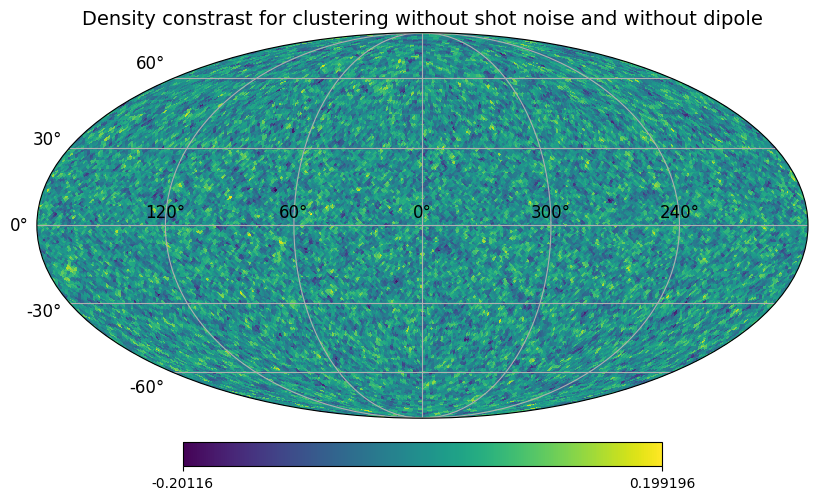

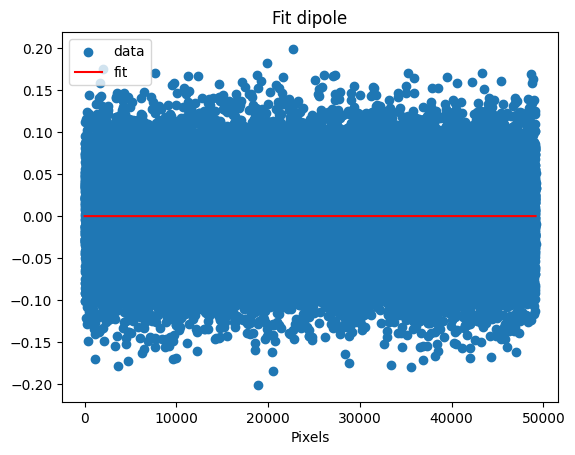

In [4]:
def get_clusterContrast(cl, nside, lognormal=False):
    m = hp.synfast(cl, nside=nside)
    if lognormal: m = np.exp(m - 0.5 * np.var(m)) #Log-Normale transformation
    return m

nest=False
lognormal=False
NSource_px_Cl = get_clusterContrast(cl, nside, lognormal=lognormal)

title="Density constrast for clustering without shot noise and without dipole"
hp.projview(NSource_px_Cl, title=title, graticule=True, graticule_labels=True)

model = lambda map, M, A, ra, dec : apply_dipole_MD(map, M, A, ra, dec, nest=nest, frame='icrs')
init =  (0, 3, 20, 40)
names = ("M", "A", "l", "b")
m = fit_dipole_err(model, NSource_px_Cl, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), fixed="M")

output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
get_saveFit_minuit(m, output_path, sufix, np.arange(0, npix), NSource_px_Cl, np.sqrt(np.abs(NSource_px_Cl)))
m

In [17]:
Ntrial = 50
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
x_fit = np.arange(0, npix)
init =  (0, 3, 20, 40)
map_cl, fit_cl = [], []
for i in range(Ntrial):
    if i % 10 == 0: print(f'i = {i}', end = '\t')
    map = get_clusterContrast(cl, nside, lognormal=False)
    map_cl.append(map)
    m = fit_dipole_err(model, map, init, names, bounds=([0, 0, 0, -90], [np.inf, 1, 360, 90]), verbose=False, plot_fig=False, fixed='M')
    fit_cl.append(m)    
    y_fit_err = np.sqrt(np.abs(map))
    get_saveFit_minuit(m, output_path, sufix, x_fit, map, y_fit_err, verbose=False)
print('Saving complete.')

i = 0	i = 10	i = 20	i = 30	i = 40	Saving complete.


## Reading DataFrame

In [6]:
output_path = "Fit_Clusters/Clusters_NoDipole/Clusters_NoDipole_"
sufix = "tests_fit"
df = pd.read_csv(output_path + sufix + '.csv')
df

,M,M_init,M_err,M_fixed,M_limits,A,A_init,A_err,A_fixed,A_limits,...,l_limits,b,b_init,b_err,b_fixed,b_limits,valid,x_fit,y_fit,y_fit_err
0,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",1.373866e-04,1.0,0.000687,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-26.393845,40.0,135.920599,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.02376521, 0.0141072 , 0.0579710...","np.array([0.15415968, 0.11877375, 0.24077171, ..."
1,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",3.484771e-05,1.0,0.002213,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-41.159416,40.0,142.916816,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.01667593, 0.04851714, 0.0344003...","np.array([0.12913533, 0.22026607, 0.18547337, ..."
2,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",1.404631e-04,1.0,0.000598,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-53.862103,40.0,133.346938,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.01427501, -0.03027255, -0.0148653...","np.array([0.11947806, 0.17399009, 0.12192348, ..."
3,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",7.201945e-08,1.0,0.001015,False,"(0.0, 1.0)",...,"(0.0, 360.0)",73.709504,40.0,155.335680,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.03642579, -0.05038996, -0.0585901...","np.array([0.19085543, 0.22447709, 0.24205406, ..."
4,0.000000e+00,0.0,0.100000,True,"(0.0, inf)",4.823562e-05,1.0,0.002160,False,"(0.0, 1.0)",...,"(0.0, 360.0)",57.929821,40.0,101.672062,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.0190555 , 0.07303884, 0.0578737...","np.array([0.13804168, 0.27025698, 0.24056969, ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,1.089667e-07,1000.0,0.001596,False,"(0.0, inf)",8.041027e-07,1.0,0.004092,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-18.439201,40.0,102.855457,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.03761789, 0.0054757 , -0.0159318...","np.array([0.19395332, 0.073998 , 0.12622143, ..."
593,6.733206e-06,1000.0,0.004126,False,"(0.0, inf)",2.006727e-06,1.0,0.004518,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.713370,40.0,150.263430,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.05265183, -0.04548844, 0.0118784...","np.array([0.22945987, 0.2132802 , 0.10898818, ..."
594,4.464434e-08,1000.0,0.003022,False,"(0.0, inf)",1.009955e-07,1.0,0.007288,False,"(0.0, 1.0)",...,"(0.0, 360.0)",84.438691,40.0,163.949555,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([-0.03745246, -0.08828277, 0.0178890...","np.array([0.19352637, 0.29712417, 0.1337499 , ..."
595,9.017072e-10,1000.0,0.017510,False,"(0.0, inf)",1.826336e-09,1.0,0.003954,False,"(0.0, 1.0)",...,"(0.0, 360.0)",-89.999818,40.0,153.644106,False,"(-90.0, 90.0)",True,"np.array([ 0, 1, 2, ..., 49149, 491...","np.array([ 0.03042208, 0.02496456, -0.0031950...","np.array([0.17441926, 0.15800179, 0.05652466, ..."


In [7]:
mask = (df['valid'] == True) #to select only valid minima in figt.
print("Nb. of non-valid minimum :", len(df[~mask]))
print(f"Ratio of non-valid minimum : {100*len(df[~mask])/len(df)} %")
df = df[mask]
print(f"Nb. of valid minimum : {len(df)}\n")
print(f"A mean = {df['A'].mean()} +/- {df['A_err'].mean()}")
print(f"A STD = {df['A'].std()}")
df[[col for col in df.columns if not col.endswith('init')]].describe()

Nb. of non-valid minimum : 16
Ratio of non-valid minimum : 2.680067001675042 %
Nb. of valid minimum : 581

A mean = 4.656340137739131e-05 +/- 0.0069277040285312735
A STD = 4.2704709180968314e-05


,M,M_err,A,A_err,l,l_err,b,b_err
count,5.810000e+02,581.000000,5.810000e+02,581.000000,5.810000e+02,581.000000,581.000000,581.000000
mean,4.912899e-06,0.050198,4.656340e-05,0.006928,1.104544e+02,261.778832,2.456804,131.664396
std,1.080539e-05,0.088384,4.270471e-05,0.048221,1.099721e+02,54.089729,59.236915,24.249753
min,0.000000e+00,0.000003,2.581060e-12,0.000010,1.976513e-07,0.349013,-90.000000,0.353839
25%,0.000000e+00,0.001822,2.006727e-06,0.001015,6.933893e+00,214.086424,-47.524648,111.461794
50%,2.853154e-10,0.005875,4.233003e-05,0.001656,8.507478e+01,261.818186,3.603727,133.031829
75%,3.589069e-06,0.100000,7.663881e-05,0.003485,1.768040e+02,308.001989,53.700415,152.757160
max,7.027329e-05,1.367503,1.889924e-04,0.934392,3.599999e+02,359.997024,90.000000,179.876434


/tmp/ipykernel_30081/4233272295.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['costheta'] = df.apply(get_costheta, axis=1)


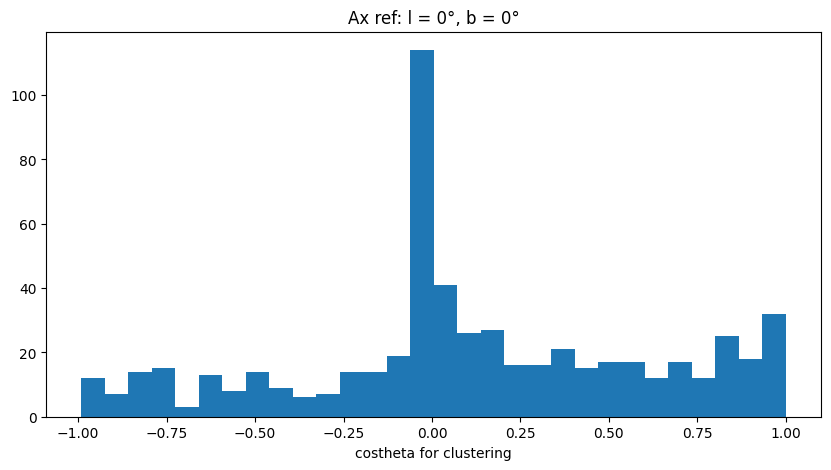

In [8]:
def get_costheta(df, lref=0, bref=0):
    data = df.copy()
    dipole = SkyCoord(l=data['l']*u.degree, b=data['b']*u.degree, frame='galactic')
    u_dipole = dipole.cartesian.xyz.value
    axref = SkyCoord(l=lref*u.degree, b=bref*u.degree, frame='galactic')
    u_ref = axref.cartesian.xyz.value
    return np.dot(u_dipole, u_ref)

df['costheta'] = df.apply(get_costheta, axis=1)
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df[col], xlabel=f"{col} for clustering", bins=30, figax=(fig, ax), title="Ax ref: l = 0°, b = 0°");

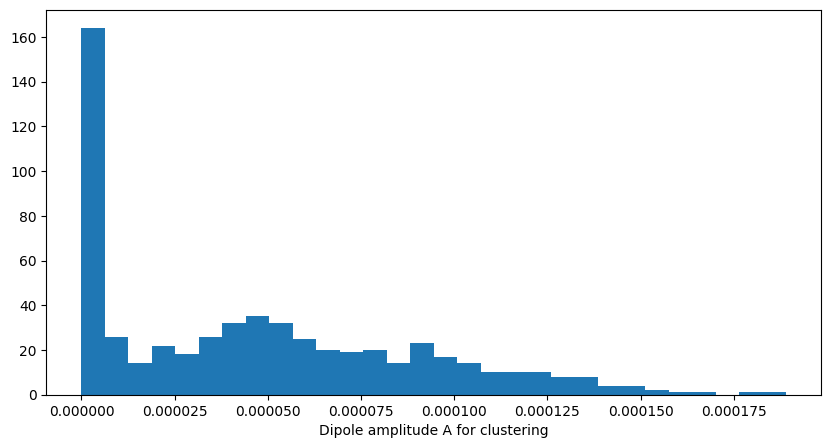

In [9]:
col = 'A'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df[col], xlabel=f"Dipole amplitude {col} for clustering", bins=30, figax=(fig, ax), show=False)
# ax.set_xscale('log')
# ax.set_yscale('log');

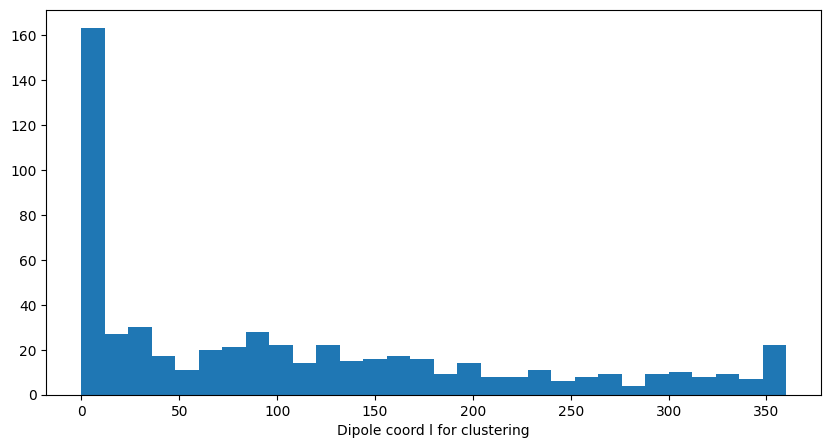

In [10]:
col = 'l'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax));

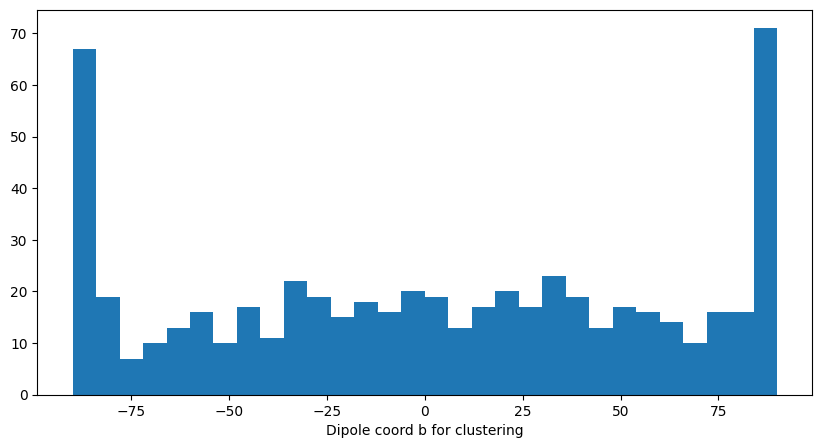

In [11]:
col = 'b'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax));

## Only M fixed

In [12]:
df_Mfixed = df[df['M_fixed']]
df_Mfixed[[col for col in df_Mfixed.columns if not col.endswith('init')]].describe()

,M,M_err,A,A_err,l,l_err,b,b_err,costheta
count,255.0,255.0,2.550000e+02,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000
mean,0.0,0.1,5.808099e-05,0.005912,84.577174,261.762490,14.077257,129.188032,0.114812
std,0.0,0.0,4.057720e-05,0.041997,93.608540,53.032385,53.686185,23.474519,0.536092
min,0.0,0.1,5.270558e-10,0.000049,0.000002,108.383681,-89.999965,90.152890,-0.990922
25%,0.0,0.1,2.670491e-05,0.000883,0.518948,214.186831,-27.845789,108.728852,-0.165645
50%,0.0,0.1,5.231259e-05,0.001442,56.543945,260.817838,18.324110,129.449049,0.064093
75%,0.0,0.1,8.781972e-05,0.002188,140.386666,307.386656,58.786732,148.681306,0.552576
max,0.0,0.1,1.551784e-04,0.648305,359.995739,359.997024,90.000000,179.876434,1.000000


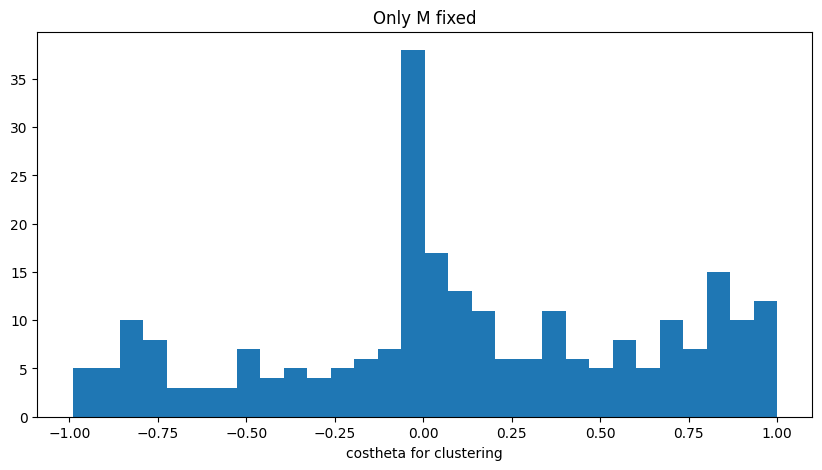

In [13]:
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(df_Mfixed[col], xlabel=f"{col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

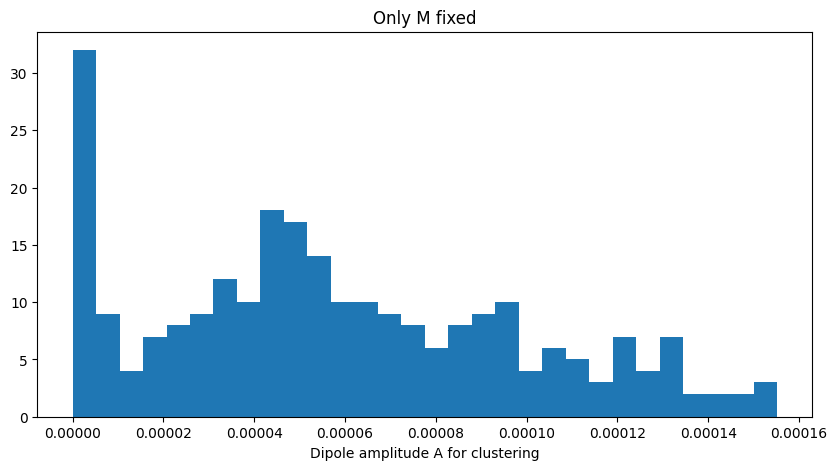

In [14]:
col = 'A'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df_Mfixed[col], xlabel=f"Dipole amplitude {col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

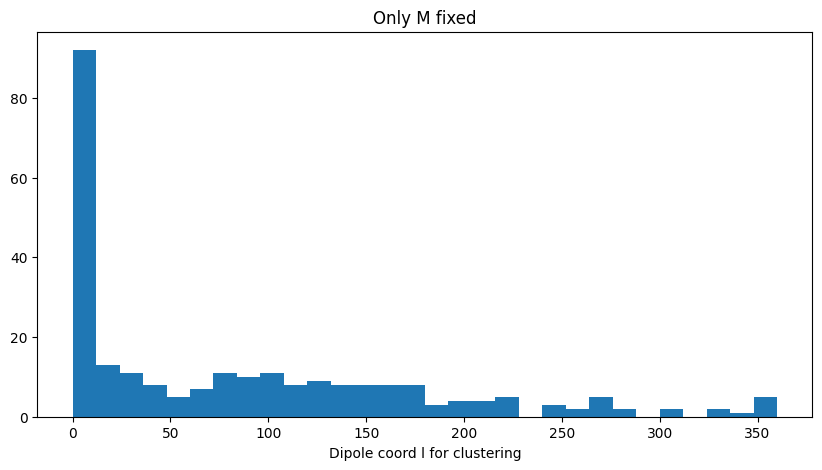

In [15]:
col = 'l'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df_Mfixed[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

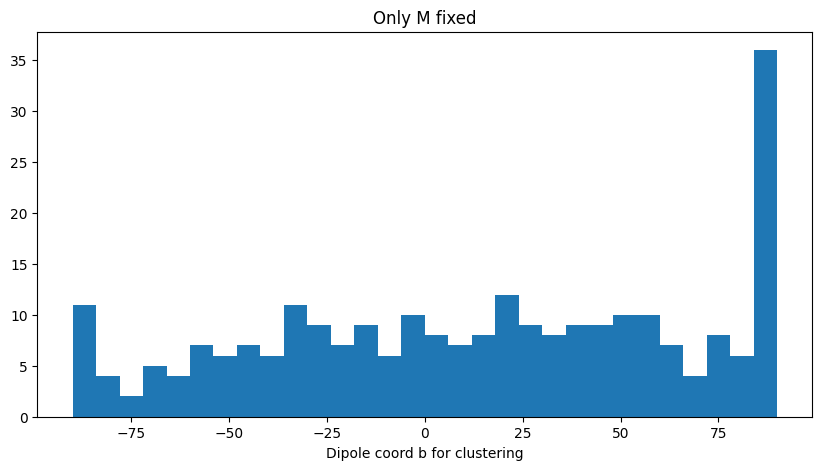

In [16]:
col = 'b'
fig, ax = plt.subplots(figsize=[10, 5])
var, bins = get_hist(df_Mfixed[col], xlabel=f"Dipole coord {col} for clustering", bins=30, figax=(fig, ax), title="Only M fixed");

## Other fit method

In [68]:
def build_mask(nside):
    npix = hp.nside2npix(nside)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    # hémisphère sud
    mask = (theta > np.pi/2).astype(float)

    # retirer plan galactique |b| < 5°
    b = np.pi/2 - theta
    mask[np.abs(b) < np.deg2rad(5)] = 0.

    return mask


def estimate_dipole_mle(counts, mask=1, nside=nside):
    npix = len(counts)
    theta, phi = hp.pix2ang(nside, np.arange(npix))

    n_hat = np.vstack([
        np.sin(theta)*np.cos(phi),
        np.sin(theta)*np.sin(phi),
        np.cos(theta)
    ]).T

    w = mask
    y = counts / np.mean(counts) - 1

    A = (n_hat.T * w) @ n_hat
    b = (n_hat.T * w) @ y

    d = np.linalg.solve(A, b)

    return d


Ntrial = 10000
map_cl, fit_cl = [], []
for i in range(Ntrial):
    if i % 1000 == 0: print(f'i = {i}', end = '\t')
    map = get_clusterContrast(cl, nside, lognormal=False)
    map_cl.append(map)
    d = estimate_dipole_mle(map, mask=build_mask(nside))
    fit_cl.append(d)

dfMC = {'A' : np.linalg.norm(fit_cl, axis=1)}
dfMC['Dx'], dfMC['Dy'], dfMC['Dz'] = tuple(np.array(fit_cl).T)
dfMC = pd.DataFrame(dfMC)
print("\nMean:", np.mean(fit_cl, axis=0))
print("Std :", np.std(fit_cl, axis=0))
print("Amplitude:", np.mean(np.linalg.norm(fit_cl, axis=1)))
dfMC

i = 0	i = 1000	i = 2000	i = 3000	i = 4000	i = 5000	i = 6000	i = 7000	i = 8000	i = 9000	
Mean: [2.03481953 1.35205877 0.80360927]
Std : [195.43522566 236.9488292   84.90622245]
Amplitude: 37.833775287492664


,A,Dx,Dy,Dz
0,5.304048,3.386183,-1.945803,3.588947
1,14.477455,7.445750,-9.068966,-8.480056
2,1.623491,0.731760,1.014146,1.035258
3,3.606055,1.693138,-2.461915,-2.018884
4,88.671624,83.827534,-2.767651,28.773971
...,...,...,...,...
9995,19.394366,6.959094,-5.581345,-17.220948
9996,1.486596,-0.136695,1.390139,-0.508721
9997,39.377126,-32.376889,-14.217889,-17.324744
9998,16.364102,5.416611,-15.286756,2.181568


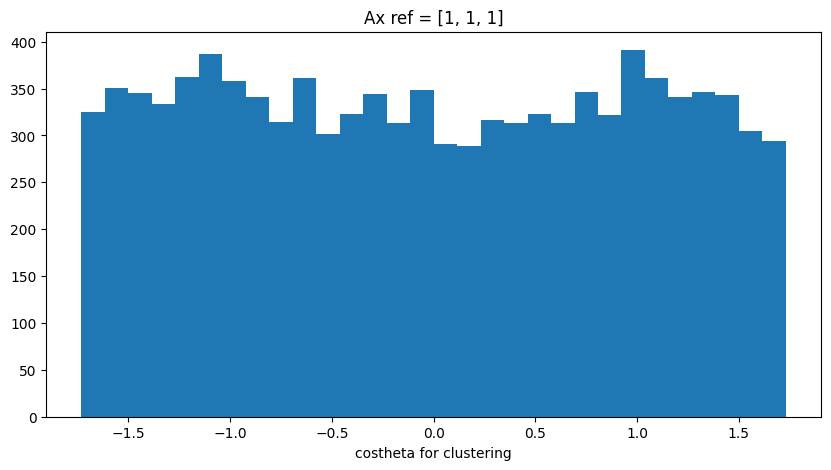

In [69]:
def get_costheta_cartesian(df, axref=[1, 1, 1]):
    data = df.copy()
    axref = np.array(axref)
    dip = np.array(data[['Dx', 'Dy', 'Dz']])
    return np.dot(dip, axref)/data['A']

dfMC['costheta'] = dfMC.apply(get_costheta_cartesian, axis=1)
col = 'costheta'
fig, ax = plt.subplots(figsize=[10, 5])
get_hist(dfMC[col], xlabel=f"{col} for clustering", bins=30, figax=(fig, ax), title="Ax ref = [1, 1, 1]");

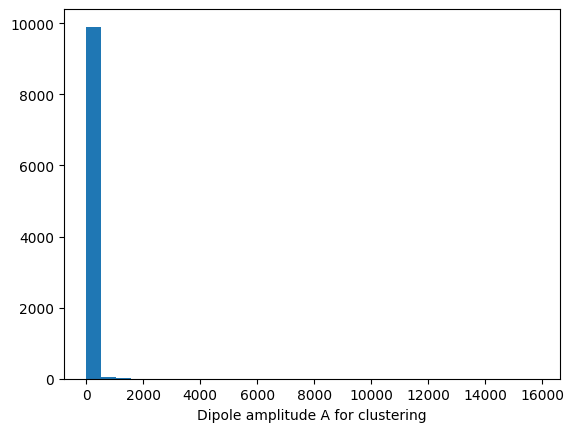

In [70]:
col = 'A'
fig, ax = plt.subplots()
get_hist(dfMC[col], xlabel=f"Dipole amplitude {col} for clustering", bins=30, figax=(fig, ax));

In [71]:
dfMC.describe()

,A,Dx,Dy,Dz,costheta
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,37.833775,2.034820,1.352059,0.803609,-0.015592
std,316.439528,195.444998,236.960678,84.910468,1.005088
min,0.206284,-3840.875012,-10099.888723,-3133.062754,-1.731408
25%,4.279649,-4.155766,-3.888903,-2.782513,-0.910609
50%,7.902271,-0.047607,-0.000533,-0.097285,-0.038464
75%,17.326344,3.741576,3.968617,2.490281,0.881865
max,15810.252967,12650.652595,15540.320466,3133.172771,1.731353
